# Fixture context — double vs single gameweek (`total_points`)
_Read-only: how double-gameweek context changes the target — separating mechanical fixture-doubling from genuine per-fixture lift, by position. The layer `composition/` and `temporal/` deferred their DGW confound to._

**Sections:** DGW prevalence · (a) raw totals, SGW vs DGW · (b) per-fixture view

---

## Setup
> Whole season, `minutes > 0`; split featured rows by `fixture_context` into SGW and DGW cohorts.

BGW rows have NULL `minutes`, so the participation filter already excludes them — only SGW and DGW survive. **Thin-DGW caveat:** ~171 DGW rows against ~11k SGW, fewer still after position splits, so every DGW statistic is small-n (n stated in each table).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from research.kernels.descriptive.distribution import (
    compute_distribution_stats,
    compare_cohorts,
)

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

# Descriptive characterisation uses the WHOLE season: GW 1 to the latest
# completed GW. No early-GW lower bound (that was a predictive-evaluation
# choice in the older EDA-1 record, not relevant here).
STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw

# Analytical population: PARTICIPATION filter, not a performance gate.
# Available players who actually featured -> minutes > 0. `minutes` can be NULL
# for some rows; minutes > 0 naturally excludes NULLs (NULL comparisons are
# False). The 60-minute performance boundary is NOT imposed here -- that
# question is deferred to the exposure/ layer. BGW rows have NULL minutes and
# are excluded by this same filter.
mart = _result.mart
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()

POSITIONS = ["GK", "DEF", "MID", "FWD"]
CONTEXTS = ["SGW", "DGW"]

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.3f}".format)

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0 (participation, not a performance gate), n = {len(df):,} player-gameweeks")
print("\nfixture_context counts (after minutes > 0 filter):")
for ctx in CONTEXTS:
    print(f"  {ctx}: {int((df['fixture_context'] == ctx).sum()):>6,}")

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0 (participation, not a performance gate), n = 11,361 player-gameweeks

fixture_context counts (after minutes > 0 filter):
  SGW: 11,190
  DGW:    171


## DGW prevalence — n per position
> How many featured rows back the DGW comparison at each position?

The count of featured player-gameweeks per `fixture_context` (SGW / DGW) by position — the sample-size table every comparison below rests on. A position with only a handful of DGW rows cannot support a confident read.

In [2]:
# n per (position, context) — sizes the cohorts for every comparison below.
_counts = df.groupby(["position", "fixture_context"]).size().unstack(fill_value=0).reset_index()
_all = pd.DataFrame([{"position": "ALL", **df["fixture_context"].value_counts().to_dict()}])
ctx_counts = pd.concat([_counts, _all], ignore_index=True)
for col in ["SGW", "DGW", "BGW"]:
    if col not in ctx_counts.columns: ctx_counts[col] = 0
ctx_counts["DGW_share_%"] = (ctx_counts["DGW"] / (ctx_counts["SGW"] + ctx_counts["DGW"]).replace(0, float("nan")) * 100).round(2)
display(ctx_counts[["position", "SGW", "DGW", "DGW_share_%"]])


,position,SGW,DGW,DGW_share_%
0,DEF,3845,59,1.510
1,FWD,1390,22,1.560
2,GK,747,10,1.320
3,MID,5208,80,1.510
4,ALL,11190,171,1.510


## (a) `total_points` distribution — SGW vs DGW by position (raw totals)
> How much more do players score in raw total during a double gameweek, and does the gap differ by position?

The full `total_points` distribution for the SGW and DGW cohorts within each position via `compare_cohorts`. A DGW row sums two fixtures into one total, so a higher DGW figure is the *expected mechanical doubling* — read the raw gap here, then section (b) separates doubling from genuine per-fixture lift (DGW cohort is small-n, tails noisy).

In [3]:
CONTEXTS = ["SGW", "DGW"]
raw_stats = (
    df[df["fixture_context"].isin(CONTEXTS)]
    .groupby(["position", "fixture_context"])["total_points"]
    .agg(["count", "mean", "median",
          lambda s: s.quantile(0.9), lambda s: s.max()])
    .rename(columns={"<lambda_0>": "p90", "<lambda_1>": "max"})
    .reset_index()
    .round(2)
)
display(raw_stats)


,position,fixture_context,count,mean,median,p90,max
0,DEF,DGW,59,5.950,5.000,13.000,19
1,DEF,SGW,3845,3.040,2.000,8.000,24
2,FWD,DGW,22,4.680,4.000,9.900,13
3,FWD,SGW,1390,2.950,2.000,8.000,19
4,GK,DGW,10,6.700,6.000,13.100,14
5,GK,SGW,747,3.340,2.000,7.000,16
6,MID,DGW,80,5.240,4.000,12.100,16
7,MID,SGW,5208,2.910,2.000,7.000,20


## (b) Per-fixture view — `total_points / fixture_count` SGW vs DGW by position
> Once we divide out the second fixture, do DGW players still outperform per fixture — is the bump real or mechanical?

The same comparison on points-per-fixture (SGW ÷ 1, DGW ÷ 2). DGW per-fixture mean ≈ SGW means the raw bump was purely mechanical; > SGW means a genuine per-fixture lift; < SGW means a per-fixture dip (rotation / fatigue). Shown as a descriptive normalisation for comparison, not a mandated treatment of the target.

In [4]:
df_ppf = df.copy()
df_ppf["points_per_fixture"] = df_ppf["total_points"] / df_ppf["fixture_count"]

ppf_rows = []
for pos in POSITIONS:
    sub = df_ppf[df_ppf.position == pos]
    cohorts = {ctx: sub[sub["fixture_context"] == ctx] for ctx in CONTEXTS}
    stats = compare_cohorts(cohorts, value_col="points_per_fixture")
    for ctx in CONTEXTS:
        s = stats.loc[ctx]
        ppf_rows.append({
            "position": pos,
            "context": ctx,
            "n": int(s["count"]) if not np.isnan(s["count"]) else 0,
            "ppf_mean": s["mean"],
            "ppf_median": s["median"],
            "ppf_std": s["std"],
        })
ppf_by_pos = pd.DataFrame(ppf_rows)
display(ppf_by_pos.round(2))

,position,context,n,ppf_mean,ppf_median,ppf_std
0,GK,SGW,747,3.340,2.000,2.700
1,GK,DGW,10,3.350,3.000,2.120
2,DEF,SGW,3845,3.040,2.000,3.130
3,DEF,DGW,59,2.970,2.500,2.260
4,MID,SGW,5208,2.910,2.000,2.840
5,MID,DGW,80,2.620,2.000,2.110
6,FWD,SGW,1390,2.950,2.000,3.130
7,FWD,DGW,22,2.340,2.000,1.850


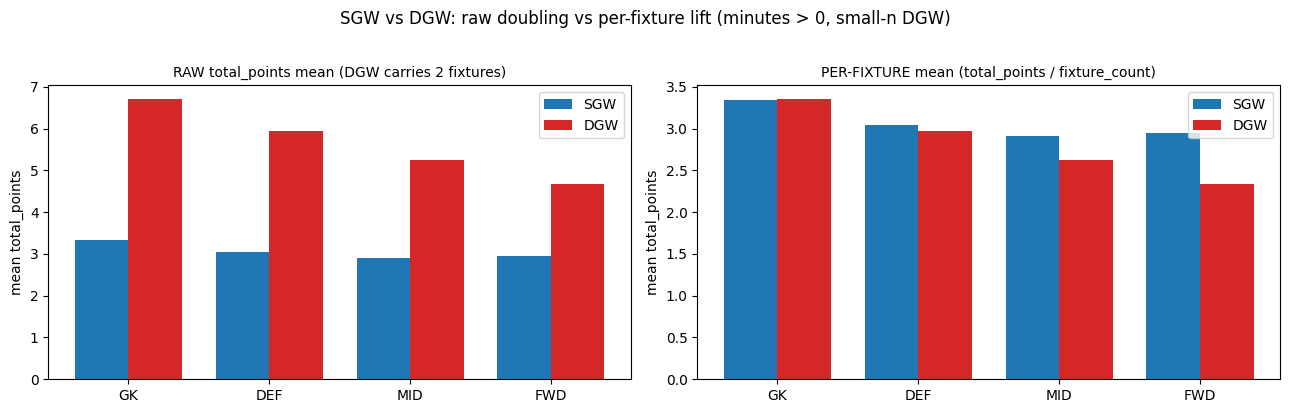

In [5]:
# Side-by-side bars reveal what the two tables hide: the RAW mean roughly
# doubles for DGW (mechanical), while the PER-FIXTURE mean sits much closer to
# SGW -- the gap between those two panels IS the mechanical-vs-real story.
colours = {"SGW": "#1f77b4", "DGW": "#d62728"}
x = np.arange(len(POSITIONS))
width = 0.38
fig, (ax_raw, ax_ppf) = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

raw_mean = raw_stats.pivot(index="position", columns="fixture_context", values="mean").reindex(POSITIONS)
ppf_mean = ppf_by_pos.pivot(index="position", columns="context", values="ppf_mean").reindex(POSITIONS)

for ax, data, title in [
    (ax_raw, raw_mean, "RAW total_points mean (DGW carries 2 fixtures)"),
    (ax_ppf, ppf_mean, "PER-FIXTURE mean (total_points / fixture_count)"),
]:
    for i, ctx in enumerate(CONTEXTS):
        ax.bar(x + (i - 0.5) * width, data[ctx].to_numpy(dtype=float),
               width, label=ctx, color=colours[ctx])
    ax.set_xticks(x)
    ax.set_xticklabels(POSITIONS)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("mean total_points")
    ax.legend()
fig.suptitle("SGW vs DGW: raw doubling vs per-fixture lift (minutes > 0, small-n DGW)", y=1.02)
plt.tight_layout()
plt.show()